# Exploratory Data Analysis — EVA (Explainable Visual Aesthetics) Dataset

The **EVA** dataset (Kang, Valenzise & Dufaux, *ATQAM/MAST'20*) collects human
aesthetic judgements of ~4,000 images (resized from the AVA dataset). For every
image, multiple subjects gave:

- an overall **score** (0–10), and
- four ordinal **aesthetic attributes** — *visual* (light & colour), *composition*,
  *quality*, *semantic* — each rated 1–4 (very bad → very good),
- a **difficulty** of judging the image (1 very difficult → 4 very easy),
- which **factors** drove their opinion (four checkboxes), and the **response time**.

Each subject also has demographics (age, region, gender, photographic expertise),
and each image is tagged with one of 6 **content categories**.

**Goal of this notebook**

1. Enumerate every feature in every table and what it means.
2. Describe the univariate distributions (scores, attributes, timing, demographics).
3. Quantify the **correlation structure** — especially *which aesthetic attribute
   best explains the overall score*.

> Data files live in `data/eva-dataset/data/`. All CSVs use `=` as the delimiter
> **except** `image_content_category.csv` (comma-separated, UTF-8-BOM).


## 0 · Setup & house style

Imports and a small, colour-blind-safe matplotlib theme (validated categorical + diverging palette; recessive grid, no top/right spines).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# --- validated, colour-blind-safe palette (light surface) --------------------
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, AQUA, YELLOW, GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
VIOLET, RED, MAGENTA, ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
CAT = [BLUE, AQUA, YELLOW, GREEN, VIOLET, RED, MAGENTA, ORANGE]           # fixed order
# diverging red<->gray<->blue for correlations (neutral gray at 0)
DIVERGING = LinearSegmentedColormap.from_list("eva_div", ["#b1201f", "#f0efec", "#184f95"])
# single-hue blue ramp for magnitude
SEQ_BLUE = LinearSegmentedColormap.from_list("eva_seq", ["#cde2fb", "#2a78d6", "#0d366b"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "text.color": INK,
    "axes.titlecolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 110, "figure.figsize": (8, 4.5),
})

def barlabels(ax, bars, fmt="{:.0f}", pad=3, color=INK2, size=9):
    # direct value labels above vertical bars (relief rule for low-contrast fills)
    for b in bars:
        ax.annotate(fmt.format(b.get_height()),
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", xytext=(0, pad),
                    textcoords="offset points", color=color, fontsize=size)

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", mpl.__version__)


pandas 3.0.3 | numpy 2.4.6 | matplotlib 3.11.0


## 1 · Load the data

Each file is read with its own delimiter/encoding, and the integer-coded fields are mapped to human-readable labels straight away. `DATA_DIR` is discovered by walking up from the notebook so this runs from anywhere in the repo.

In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "data" / "eva-dataset" / "data"
        if cand.exists():
            return cand
    raise FileNotFoundError("Could not locate data/eva-dataset/data")

DATA_DIR = find_data_dir()
print("DATA_DIR =", DATA_DIR)

# --- code -> label dictionaries (from readme.md) ------------------------------
GENDER   = {1.0: "Male", 2.0: "Female"}
PHOTO    = {0.0: "None", 1.0: "Beginner", 2.0: "Amateur", 3.0: "Professional"}
DIFF_LBL = {1: "very difficult", 2: "difficult", 3: "easy", 4: "very easy"}
ATTR_LBL = {1: "very bad", 2: "bad", 3: "good", 4: "very good"}
FACTORS  = {"1": "light & colour", "2": "composition & depth", "3": "quality", "4": "semantic"}
ATTRS    = ["visual", "composition", "quality", "semantic"]
REF_YEAR = 2020  # experiment year (paper is ATQAM/MAST'20; Chrome/80 user-agents)

# --- votes_filtered.csv : the filtered ballots used in the paper --------------
votes = pd.read_csv(DATA_DIR / "votes_filtered.csv", sep="=")
votes = votes.rename(columns={k: f"factor_{v.split()[0].lower()}" for k, v in FACTORS.items()})
FACTOR_COLS = [f"factor_{v.split()[0].lower()}" for v in FACTORS.values()]

# --- users.csv ----------------------------------------------------------------
users = pd.read_csv(DATA_DIR / "users.csv", sep="=")
users["gender"]     = users["gender_id"].map(GENDER)
users["photo_level"] = users["photographic_level_id"].map(PHOTO)
users["birth_year"] = users["age"]
users["age_years"]  = REF_YEAR - users["birth_year"]

# --- region_index.csv : region code -> country (no header) --------------------
regions = pd.read_csv(DATA_DIR / "region_index.csv", sep="=", header=None,
                      names=["region_code", "region_name"])
reg_map = dict(zip(regions["region_code"], regions["region_name"]))
users["region_name"] = users["region"].astype("Int64").map(reg_map)

# --- image_content_category.csv : comma + UTF-8 BOM ---------------------------
categories = pd.read_csv(DATA_DIR / "image_content_category.csv", encoding="utf-8-sig")
categories = categories.rename(columns={"sort": "category"})

# --- one wide analysis frame: every ballot + image category + voter profile ---
df = (votes
      .merge(categories, on="image_id", how="left")
      .merge(users[["id", "gender", "photo_level", "age_years", "region_name"]],
             left_on="user_id", right_on="id", how="left")
      .drop(columns="id"))

print(f"votes_filtered : {votes.shape[0]:,} ballots x {votes.shape[1]} cols")
print(f"users          : {users.shape[0]:,} subjects")
print(f"regions        : {regions.shape[0]:,} region codes")
print(f"categories     : {categories.shape[0]:,} images, {categories['category'].nunique()} categories")
print(f"merged df      : {df.shape[0]:,} rows x {df.shape[1]} cols")


DATA_DIR = /shared/amin/code/playground/image-society/data/eva-dataset/data
votes_filtered : 136,943 ballots x 13 cols
users          : 2,133 subjects
regions        : 249 region codes
categories     : 5,101 images, 6 categories
merged df      : 136,943 rows x 18 cols


## 2 · Dataset overview & feature dictionary

In [3]:
for name, t in [("votes_filtered", votes), ("users", users), ("categories", categories)]:
    na = t.isna().sum()
    print(f"\n=== {name} : {t.shape[0]:,} rows x {t.shape[1]} cols ===")
    print("columns with missing values:",
          {c: int(na[c]) for c in na.index if na[c]} or "none")
votes.head()



=== votes_filtered : 136,943 rows x 13 cols ===
columns with missing values: none

=== users : 2,133 rows x 11 cols ===
columns with missing values: {'eyecheck': 731}

=== categories : 5,101 rows x 2 cols ===
columns with missing values: none


,image_id,user_id,score,difficulty,visual,composition,quality,semantic,vote_time,factor_light,factor_composition,factor_quality,factor_semantic
0,71,C1412,7.0,2.0,3.0,3.0,4.0,3.0,11.0,0,0,1,0
1,71,C1417,6.0,2.0,3.0,3.0,3.0,3.0,23.0,0,1,0,0
2,71,C1431,3.0,2.0,2.0,2.0,3.0,2.0,24.0,0,0,0,1
3,71,C1465,4.0,3.0,2.0,2.0,3.0,3.0,11.0,0,1,0,0
4,71,C1490,5.0,1.0,3.0,2.0,3.0,2.0,11.0,0,1,0,1


In [4]:
# --- explicit feature dictionary -------------------------------------------
feature_dict = pd.DataFrame([
    ("votes_filtered", "image_id",     "int",     "Image name in AVA (join key to categories)"),
    ("votes_filtered", "user_id",      "str",     "Subject id (join key to users)"),
    ("votes_filtered", "score",        "int 0-10","Overall aesthetic score (the target)"),
    ("votes_filtered", "difficulty",   "ord 1-4", "1 very difficult -> 4 very easy to judge"),
    ("votes_filtered", "visual",       "ord 1-4", "Light & colour attribute (very bad->very good)"),
    ("votes_filtered", "composition",  "ord 1-4", "Composition attribute (very bad->very good)"),
    ("votes_filtered", "quality",      "ord 1-4", "Technical quality attribute"),
    ("votes_filtered", "semantic",     "ord 1-4", "Semantic/meaning attribute"),
    ("votes_filtered", "vote_time",    "float s", "Seconds since previous submission (response time)"),
    ("votes_filtered", "factor_light",       "bin", "Voter cited light & colour"),
    ("votes_filtered", "factor_composition", "bin", "Voter cited composition & depth"),
    ("votes_filtered", "factor_quality",     "bin", "Voter cited quality"),
    ("votes_filtered", "factor_semantic",    "bin", "Voter cited semantic"),
    ("users", "age (birth_year)", "int", "Subject's birth year -> age = 2020 - birth_year"),
    ("users", "region",           "code","Region code (mapped via region_index.csv)"),
    ("users", "photographic_level_id", "code", "0 none,1 Beginner,2 Amateur,3 Professional"),
    ("users", "gender_id",        "code","1 male, 2 female"),
    ("users", "eyecheck",         "code","1 glasses, 2 colour-blind, 1,2 both, blank none"),
    ("categories", "image_id",    "int", "Image name in AVA"),
    ("categories", "category",    "cat 1-6", "Content category (6 classes; named in paper)"),
], columns=["table", "feature", "type", "meaning"])
feature_dict


,table,feature,type,meaning
0,votes_filtered,image_id,int,Image name in AVA (join key to categories)
1,votes_filtered,user_id,str,Subject id (join key to users)
2,votes_filtered,score,int 0-10,Overall aesthetic score (the target)
3,votes_filtered,difficulty,ord 1-4,1 very difficult -> 4 very easy to judge
4,votes_filtered,visual,ord 1-4,Light & colour attribute (very bad->very good)
5,votes_filtered,composition,ord 1-4,Composition attribute (very bad->very good)
6,votes_filtered,quality,ord 1-4,Technical quality attribute
7,votes_filtered,semantic,ord 1-4,Semantic/meaning attribute
8,votes_filtered,vote_time,float s,Seconds since previous submission (response time)
9,votes_filtered,factor_light,bin,Voter cited light & colour


## 3 · Univariate distributions

### 3.1 Overall score (0–10)

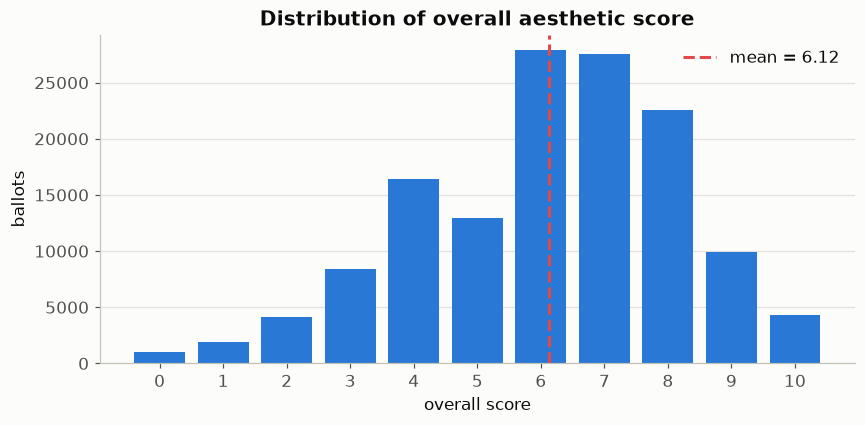

count    136943.00
mean          6.12
std           2.05
min           0.00
25%           5.00
50%           6.00
75%           8.00
max          10.00


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sc = votes["score"].value_counts().sort_index()
bars = ax.bar(sc.index, sc.values, color=BLUE, width=0.8)
mean_s = votes["score"].mean()
ax.axvline(mean_s, color=RED, lw=2, ls="--", label=f"mean = {mean_s:.2f}")
ax.set(xlabel="overall score", ylabel="ballots", title="Distribution of overall aesthetic score")
ax.set_xticks(range(0, 11)); ax.grid(axis="x", visible=False)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(votes["score"].describe().round(2).to_string())


### 3.2 The four aesthetic attributes and difficulty (ordinal 1–4)

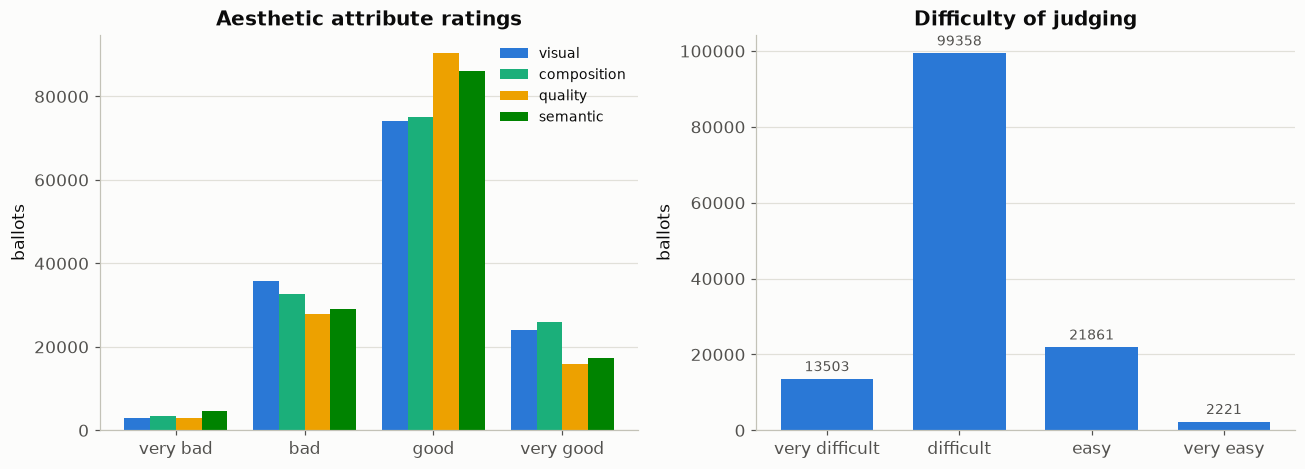

mean attribute ratings (1-4):


visual         2.872
composition    2.900
quality        2.867
semantic       2.848


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
levels = [1, 2, 3, 4]
# grouped bars: one series per attribute
w = 0.2
x = np.arange(len(levels))
for k, a in enumerate(ATTRS):
    counts = [(votes[a] == lv).sum() for lv in levels]
    axes[0].bar(x + (k - 1.5) * w, counts, w, label=a, color=CAT[k])
axes[0].set_xticks(x, [ATTR_LBL[l] for l in levels])
axes[0].set(ylabel="ballots", title="Aesthetic attribute ratings")
axes[0].grid(axis="x", visible=False); axes[0].legend(frameon=False, fontsize=9)

# difficulty
dc = votes["difficulty"].value_counts().reindex(levels)
b = axes[1].bar(x, dc.values, color=BLUE, width=0.7)
barlabels(axes[1], b)
axes[1].set_xticks(x, [DIFF_LBL[l] for l in levels])
axes[1].set(ylabel="ballots", title="Difficulty of judging")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("mean attribute ratings (1-4):")
print(votes[ATTRS].mean().round(3).to_string())


### 3.3 Response time (`vote_time`)

Heavily right-skewed — most ballots take a few tens of seconds, but idle sessions produce extreme outliers (max > 6M s). Shown on a log x-axis, clipped at the 99.9th percentile.

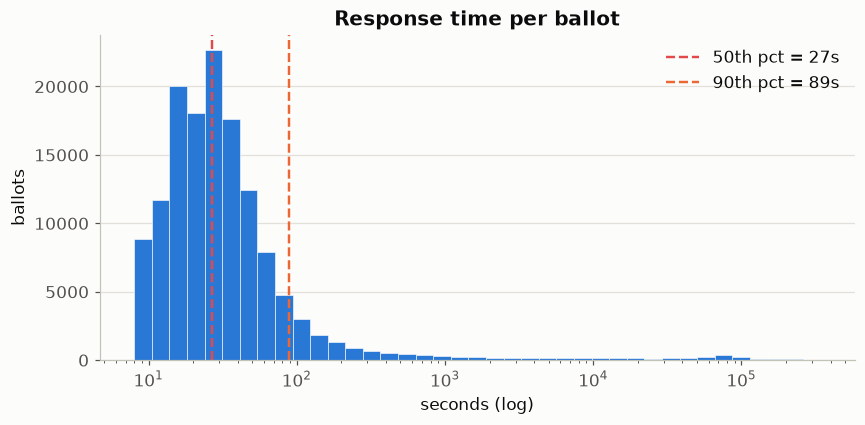

count     136943.0
mean        2009.0
std        42146.9
min            8.0
50%           27.0
90%           89.0
99%        38637.9
max      6219213.0


In [7]:
vt = votes["vote_time"]
disp = vt[vt <= vt.quantile(0.999)]
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(np.log10(max(vt.min(), 1)), np.log10(disp.max()), 40)
ax.hist(disp, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
for q, c in [(0.5, RED), (0.9, ORANGE)]:
    ax.axvline(vt.quantile(q), color=c, ls="--", lw=1.6,
               label=f"{int(q*100)}th pct = {vt.quantile(q):.0f}s")
ax.set_xscale("log")
ax.set(xlabel="seconds (log)", ylabel="ballots", title="Response time per ballot")
ax.grid(axis="x", visible=False); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(vt.describe(percentiles=[.5, .9, .99]).round(1).to_string())


### 3.4 Which factors do voters cite? · 3.5 Image content categories

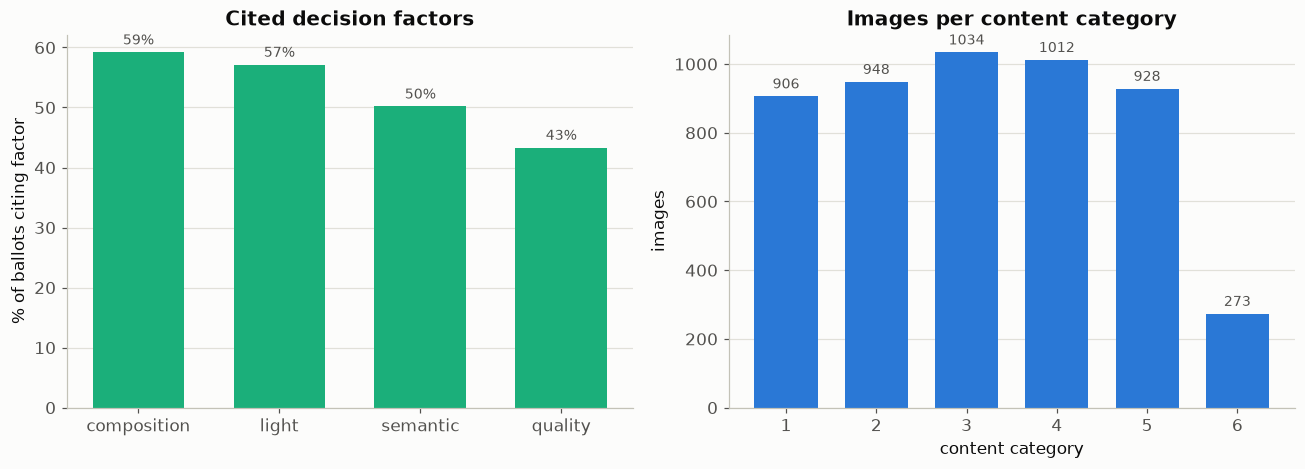

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

rates = votes[FACTOR_COLS].mean().sort_values(ascending=False)
labels = [c.replace("factor_", "") for c in rates.index]
b = axes[0].bar(labels, rates.values * 100, color=AQUA, width=0.65)
barlabels(axes[0], b, fmt="{:.0f}%")
axes[0].set(ylabel="% of ballots citing factor", title="Cited decision factors")
axes[0].grid(axis="x", visible=False)

cc = categories["category"].value_counts().sort_index()
b = axes[1].bar(cc.index.astype(int).astype(str), cc.values, color=BLUE, width=0.7)
barlabels(axes[1], b)
axes[1].set(xlabel="content category", ylabel="images",
            title="Images per content category")
axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()


## 4 · Who are the voters? (subject demographics)

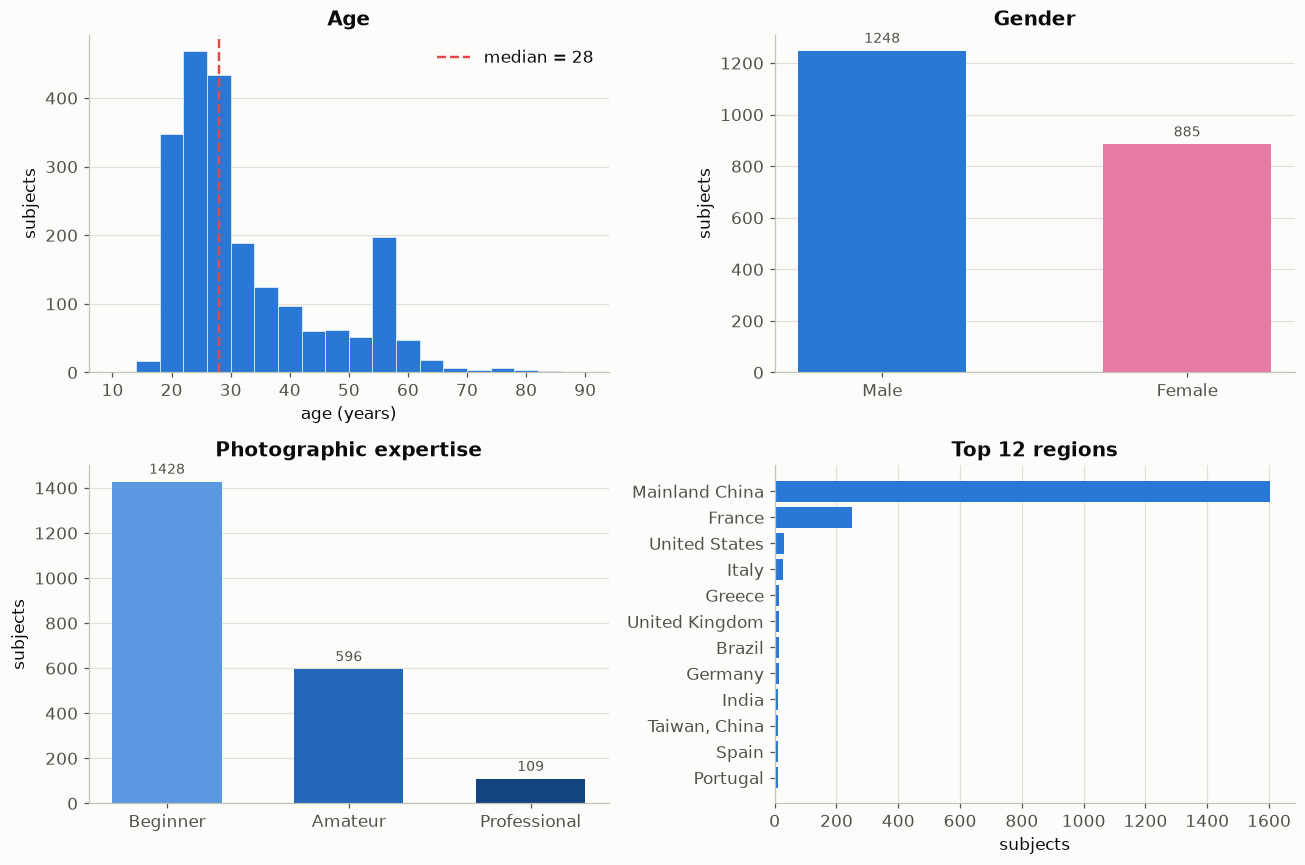

unique voters in filtered ballots: 1,094 of 2,133 registered subjects


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# age
age_ok = users["age_years"][(users["age_years"] >= 10) & (users["age_years"] <= 90)]
axes[0, 0].hist(age_ok, bins=range(10, 92, 4), color=BLUE, edgecolor=SURFACE, linewidth=0.4)
axes[0, 0].axvline(age_ok.median(), color=RED, ls="--", lw=1.6,
                   label=f"median = {age_ok.median():.0f}")
axes[0, 0].set(xlabel="age (years)", ylabel="subjects", title="Age")
axes[0, 0].grid(axis="x", visible=False); axes[0, 0].legend(frameon=False)

# gender
gc = users["gender"].value_counts()
b = axes[0, 1].bar(gc.index, gc.values, color=[BLUE, MAGENTA], width=0.55)
barlabels(axes[0, 1], b)
axes[0, 1].set(ylabel="subjects", title="Gender"); axes[0, 1].grid(axis="x", visible=False)

# photographic level
order = ["None", "Beginner", "Amateur", "Professional"]
pc = users["photo_level"].value_counts().reindex(order).dropna()
b = axes[1, 0].bar(pc.index, pc.values, color=SEQ_BLUE(np.linspace(0.35, 0.9, len(pc))), width=0.6)
barlabels(axes[1, 0], b)
axes[1, 0].set(ylabel="subjects", title="Photographic expertise")
axes[1, 0].grid(axis="x", visible=False)

# top regions
tr = users["region_name"].value_counts().head(12).sort_values()
axes[1, 1].barh(tr.index, tr.values, color=BLUE)
axes[1, 1].set(xlabel="subjects", title="Top 12 regions")
axes[1, 1].grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"unique voters in filtered ballots: {votes['user_id'].nunique():,} "
      f"of {users.shape[0]:,} registered subjects")


## 5 · Coverage & sparsity

How many ballots per image, and how active is each voter? The experiment tightly controlled ballots-per-image (each image got ~30+).

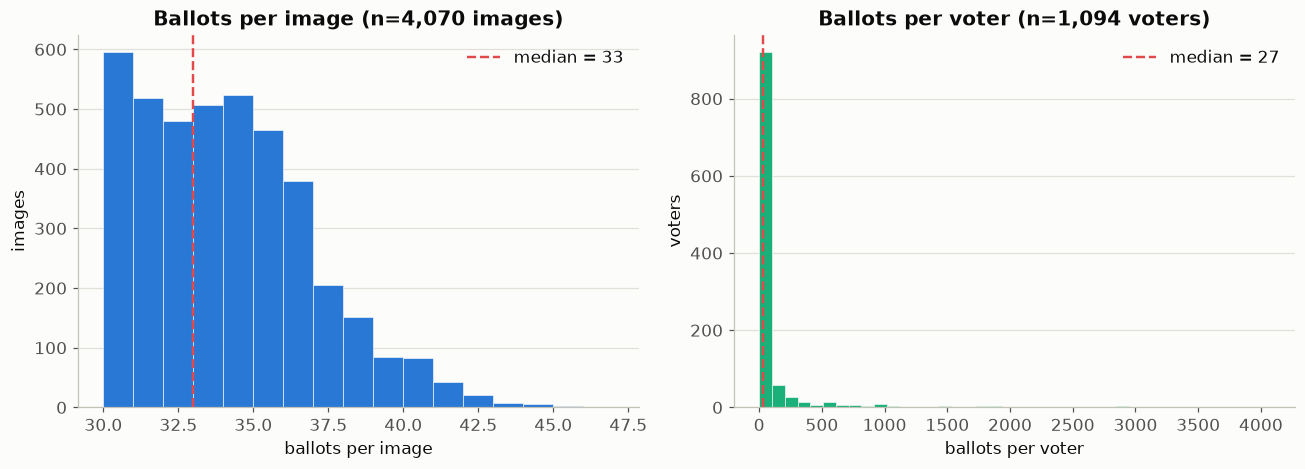

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

per_img = votes.groupby("image_id").size()
axes[0].hist(per_img, bins=range(per_img.min(), per_img.max() + 2), color=BLUE,
             edgecolor=SURFACE, linewidth=0.4)
axes[0].axvline(per_img.median(), color=RED, ls="--", lw=1.6,
                label=f"median = {per_img.median():.0f}")
axes[0].set(xlabel="ballots per image", ylabel="images",
            title=f"Ballots per image (n={per_img.size:,} images)")
axes[0].grid(axis="x", visible=False); axes[0].legend(frameon=False)

per_user = votes.groupby("user_id").size()
axes[1].hist(per_user, bins=40, color=AQUA, edgecolor=SURFACE, linewidth=0.4)
axes[1].axvline(per_user.median(), color=RED, ls="--", lw=1.6,
                label=f"median = {per_user.median():.0f}")
axes[1].set(xlabel="ballots per voter", ylabel="voters",
            title=f"Ballots per voter (n={per_user.size:,} voters)")
axes[1].grid(axis="x", visible=False); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()


## 6 · Correlation structure — the core question

The four attributes are **ordinal** (1–4) and the score is 0–10, so **Spearman rank
correlation** is the appropriate measure at the individual-ballot level. Because
single ballots are noisy, we also aggregate to the **image level** (mean score & mean
attribute per image, ~30 ballots each) where the aesthetic signal is far cleaner —
there **Pearson** is meaningful.

### 6.1 Ballot-level Spearman correlations

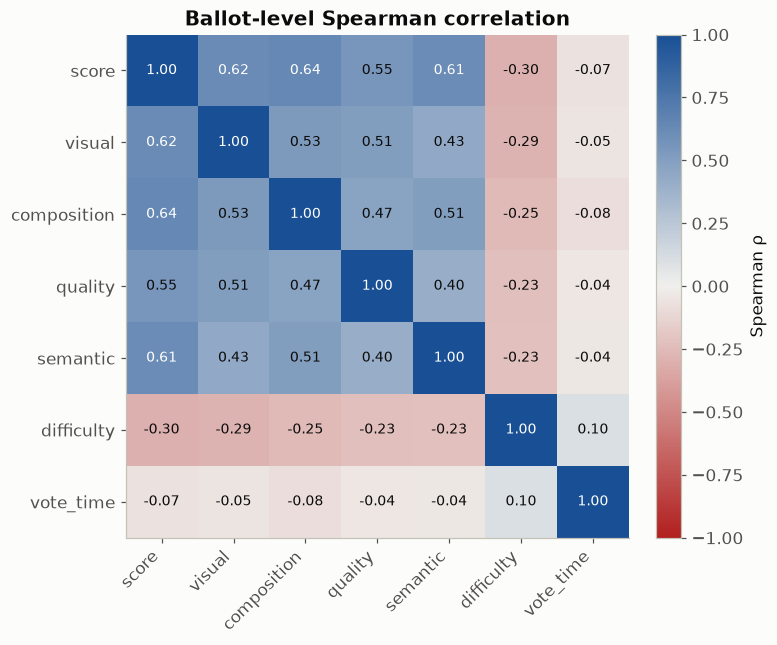

Spearman correlation of each feature with overall score:
composition    0.638
visual         0.624
semantic       0.611
quality        0.549
vote_time     -0.069
difficulty    -0.303


In [11]:
def heatmap(ax, corr, title):
    im = ax.imshow(corr.values, cmap=DIVERGING, vmin=-1, vmax=1)
    n = corr.shape[0]
    ax.set_xticks(range(n), corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(n), corr.index)
    for i in range(n):
        for j in range(n):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.55 else INK)
    ax.set_title(title); ax.grid(False)
    return im

num_cols = ["score", "visual", "composition", "quality", "semantic",
            "difficulty", "vote_time"]
sp = votes[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6))
im = heatmap(ax, sp, "Ballot-level Spearman correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
plt.tight_layout(); plt.show()

print("Spearman correlation of each feature with overall score:")
print(sp["score"].drop("score").sort_values(ascending=False).round(3).to_string())


### 6.2 Image-level Pearson correlations (aggregated, cleaner signal)

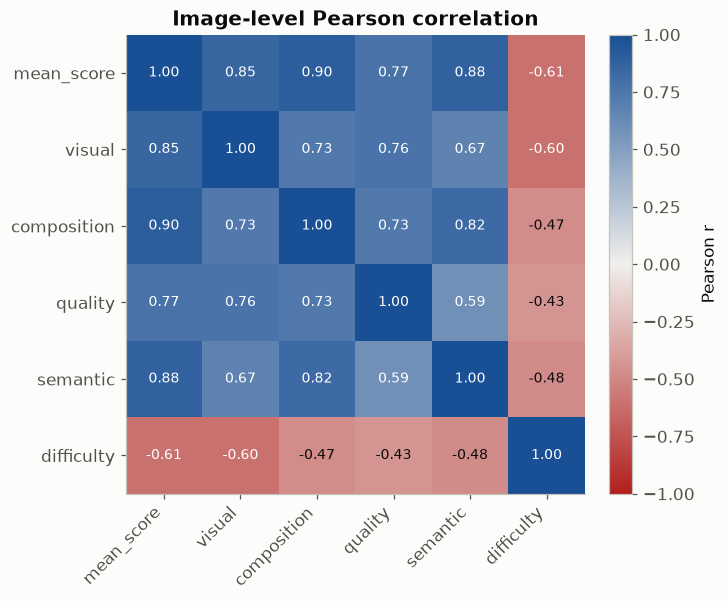

Image-level Pearson correlation with mean score:
composition    0.899
semantic       0.878
visual         0.848
quality        0.773
difficulty    -0.607


In [12]:
img = votes.groupby("image_id").agg(
    mean_score=("score", "mean"),
    visual=("visual", "mean"), composition=("composition", "mean"),
    quality=("quality", "mean"), semantic=("semantic", "mean"),
    difficulty=("difficulty", "mean"),
)
pc = img.corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 5.6))
im = heatmap(ax, pc, "Image-level Pearson correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
plt.tight_layout(); plt.show()

print("Image-level Pearson correlation with mean score:")
print(pc["mean_score"].drop("mean_score").sort_values(ascending=False).round(3).to_string())


### 6.3 The strongest driver — mean composition vs. mean score

Composition is the attribute most tightly coupled to overall aesthetics.

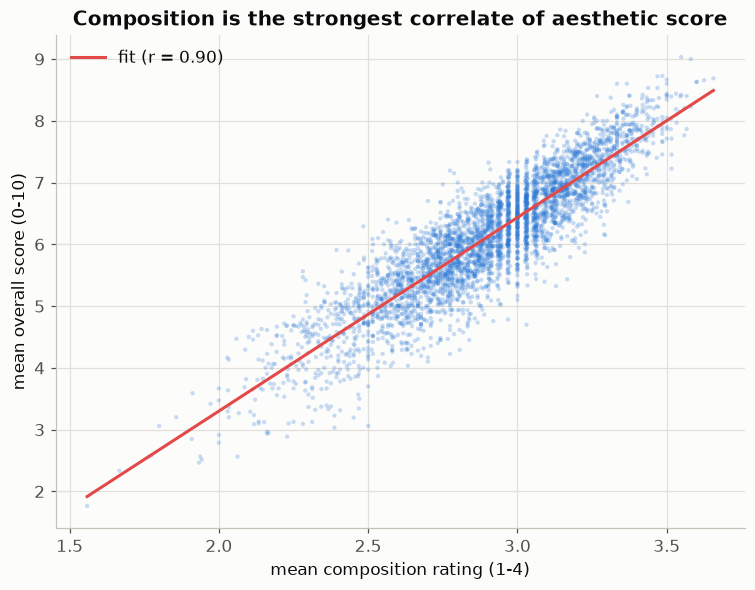

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(img["composition"], img["mean_score"], s=8, alpha=0.25, color=BLUE,
           edgecolors="none")
# linear fit
m, b = np.polyfit(img["composition"], img["mean_score"], 1)
xs = np.linspace(img["composition"].min(), img["composition"].max(), 50)
r = stats.pearsonr(img["composition"], img["mean_score"])[0]
ax.plot(xs, m * xs + b, color=RED, lw=2, label=f"fit (r = {r:.2f})")
ax.set(xlabel="mean composition rating (1-4)", ylabel="mean overall score (0-10)",
       title="Composition is the strongest correlate of aesthetic score")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


### 6.4 Does score depend on content category, expertise, or gender?

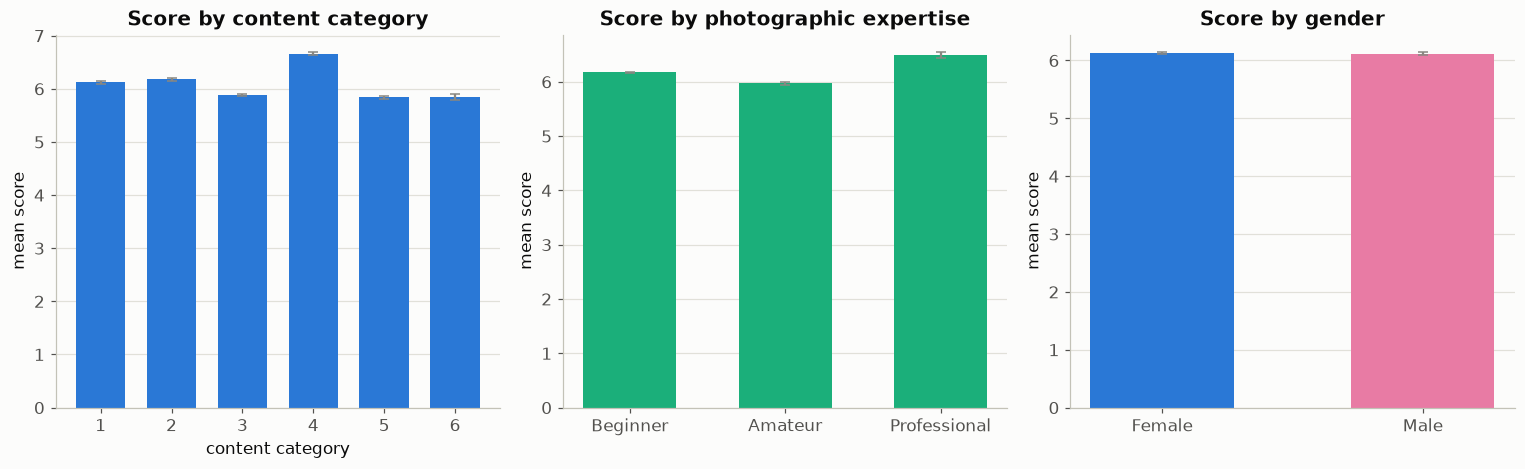

mean score by content category:
 category
1    6.12
2    6.18
3    5.88
4    6.66
5    5.84
6    5.84


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

def mean_ci(group):
    g = group.agg(["mean", "sem", "size"])
    g["ci"] = g["sem"] * 1.96
    return g

cat_stats = mean_ci(df.groupby("category")["score"])
b = axes[0].bar(cat_stats.index.astype(int).astype(str), cat_stats["mean"],
                yerr=cat_stats["ci"], color=BLUE, width=0.7, capsize=3,
                error_kw=dict(ecolor=MUTED))
axes[0].set(xlabel="content category", ylabel="mean score",
            title="Score by content category")
axes[0].grid(axis="x", visible=False)

order = ["Beginner", "Amateur", "Professional"]
ps = mean_ci(df.groupby("photo_level")["score"]).reindex(order).dropna()
b = axes[1].bar(ps.index, ps["mean"], yerr=ps["ci"], color=AQUA, width=0.6,
                capsize=3, error_kw=dict(ecolor=MUTED))
axes[1].set(ylabel="mean score", title="Score by photographic expertise")
axes[1].grid(axis="x", visible=False)

gs = mean_ci(df.groupby("gender")["score"])
b = axes[2].bar(gs.index, gs["mean"], yerr=gs["ci"], color=[BLUE, MAGENTA],
                width=0.55, capsize=3, error_kw=dict(ecolor=MUTED))
axes[2].set(ylabel="mean score", title="Score by gender")
axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

# how tightly do image means span the scale?
print("mean score by content category:\n",
      cat_stats["mean"].round(2).to_string())


## 7 · Key findings

In [15]:
with_score = sp["score"].drop("score")
best = with_score.idxmax()
print("=" * 64)
print("EVA DATASET — EDA SUMMARY")
print("=" * 64)
print(f"{votes.shape[0]:,} ballots | {votes['image_id'].nunique():,} images | "
      f"{votes['user_id'].nunique():,} voters")
print(f"~{votes.groupby('image_id').size().median():.0f} ballots/image (min "
      f"{votes.groupby('image_id').size().min()})")
print(f"mean overall score = {votes['score'].mean():.2f} / 10  "
      f"(sd {votes['score'].std():.2f})")
print("-" * 64)
print("Correlation with overall score:")
print("  ballot-level Spearman (strongest -> weakest):")
for k, v in with_score.sort_values(ascending=False).items():
    print(f"    {k:<12} {v:+.3f}")
print(f"  -> strongest positive driver at ballot level: '{best}'")
print("  image-level Pearson with mean score:")
for k, v in pc["mean_score"].drop("mean_score").sort_values(ascending=False).items():
    print(f"    {k:<12} {v:+.3f}")
print("-" * 64)
print("Takeaways:")
print("  * Composition / semantic / visual are the top correlates of score;")
print("    quality matters least of the four attributes.")
print("  * Difficulty is NEGATIVELY related — hard-to-judge images score lower.")
print("  * vote_time is essentially uncorrelated with score (rho ~ -0.07).")
print("  * Aggregating to image level sharpens every correlation (0.77-0.90).")


EVA DATASET — EDA SUMMARY
136,943 ballots | 4,070 images | 1,094 voters
~33 ballots/image (min 30)
mean overall score = 6.12 / 10  (sd 2.05)
----------------------------------------------------------------
Correlation with overall score:
  ballot-level Spearman (strongest -> weakest):
    composition  +0.638
    visual       +0.624
    semantic     +0.611
    quality      +0.549
    vote_time    -0.069
    difficulty   -0.303
  -> strongest positive driver at ballot level: 'composition'
  image-level Pearson with mean score:
    composition  +0.899
    semantic     +0.878
    visual       +0.848
    quality      +0.773
    difficulty   -0.607
----------------------------------------------------------------
Takeaways:
  * Composition / semantic / visual are the top correlates of score;
    quality matters least of the four attributes.
  * Difficulty is NEGATIVELY related — hard-to-judge images score lower.
  * vote_time is essentially uncorrelated with score (rho ~ -0.07).
  * Aggregati

### Narrative summary

**Features.** The dataset is a *ballot table* (`votes_filtered.csv`, 136,943 rows) — one
row per subject-image judgement — joined to a *subject table* (`users.csv`) and an
*image-category table*. Each ballot carries an overall **score (0–10)**, four ordinal
**aesthetic attributes** (visual, composition, quality, semantic; 1–4), a **difficulty**
rating, four binary **decision-factor** flags, and a **response time**. Subjects have
age, region, gender and photographic expertise; images have one of six content
categories.

**Correlation — the headline.**

- **Composition is the strongest correlate of the overall score** (ballot-level
  Spearman ρ ≈ 0.64; image-level Pearson r ≈ 0.90), followed closely by **semantic**
  and **visual** (light & colour). **Quality** is the weakest of the four (ρ ≈ 0.55 /
  r ≈ 0.77) — technically sound images are not necessarily rated beautiful.
- The four attributes are moderately inter-correlated (ρ ≈ 0.4–0.5), i.e. they capture
  overlapping but distinct facets of aesthetics.
- **Difficulty is negatively correlated** with score (ρ ≈ −0.30): images that are hard
  to judge tend to receive lower scores.
- **Response time carries almost no aesthetic signal** (ρ ≈ −0.07) — how long someone
  looked does not predict how much they liked the image.
- Scores vary only mildly across **content categories**, and differences by
  **photographic expertise** and **gender** are small relative to the attribute signal
  — aesthetic judgement in EVA is driven far more by *what the image is* than by *who is
  looking*.

**Data-quality notes.** Coverage is deliberately balanced (~30–46 ballots per image);
`vote_time` has extreme right-tail outliers (idle sessions) and should be
log-transformed or clipped; `photographic_level` has no `0/None` subjects in practice;
and the six content-category codes are numeric here (their names are defined in the
paper, not in the shipped CSVs).
